# Spotify EDA

## Objective
Explore genre-level differences in Spotify tracks, with a focus on popularity and audio features.

## Notebook structure
1. Data loading
2. Data cleaning
3. Descriptive statistics
4. Popularity distribution
5. Genre-level comparisons
6. Correlation analysis
7. Multivariate visualization
8. Distance-based similarity analysis

In [16]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## 1. Load data

In [17]:
# Download latest version
path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")
#print(os.listdir(path)) #this helps understand what's inside the directory
file_path = os.path.join(path, "dataset.csv")
dataset = pd.read_csv(file_path)
print("Path to dataset files:", path)
print("First 5 records:\n")
dataset.head()

Path to dataset files: C:\Users\ranik\.cache\kagglehub\datasets\maharshipandya\-spotify-tracks-dataset\versions\1
First 5 records:



,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Feature selection
Album name and track name are excluded from the analysis because they are identifiers rather than analytical variables.

In [18]:
df = dataset.copy()

In [19]:
df["explicit"] = [1 if i == True else 0 for i in df["explicit"]]

In [20]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

## 2. Clean data
- convert boolean columns
- check missing values
- remove incomplete rows
- inspect duplicates

In [21]:
#check for missing values
missing = df.isna().sum()
missing = missing[missing > 0]
missing

artists       1
album_name    1
track_name    1
dtype: int64

In [22]:
#how many rows have missing values?
missing = df[df.isna().any(axis=1)]
len(missing)

1

In [23]:
#removing rows with missing values
print(f"rows before removal: {len(df)}")
df = df.dropna()
print(f"rows after removal: {len(df)}")

rows before removal: 114000
rows after removal: 113999


In [24]:
#check
missing = df.isna().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("there are no missing values")
else:
    print(f"missing values: {missing}")

there are no missing values


In [25]:
#check for rows with spaced values
spaced_values=df.eq(" ").sum()
spaced_values = spaced_values[spaced_values >0]
spaced_values

Series([], dtype: int64)

In [26]:
duplicate = df[df.duplicated()]
display(duplicate.T)
#df.duplicated().sum()

""
Unnamed: 0
track_id
artists
album_name
track_name
popularity
duration_ms
explicit
danceability
energy


## 3. Descriptive overview

In [27]:
summary = round(df.describe().T,2).reset_index()
summary

,index,count,mean,std,min,25%,50%,75%,max
0,Unnamed: 0,113999.0,56999.42,32909.24,0.00,28499.50,56999.00,85499.50,113999.00
1,popularity,113999.0,33.24,22.30,0.00,17.00,35.00,50.00,100.00
2,duration_ms,113999.0,228031.15,107296.06,8586.00,174066.00,212906.00,261506.00,5237295.00
3,explicit,113999.0,0.09,0.28,0.00,0.00,0.00,0.00,1.00
4,danceability,113999.0,0.57,0.17,0.00,0.46,0.58,0.70,0.98
5,energy,113999.0,0.64,0.25,0.00,0.47,0.68,0.85,1.00
6,key,113999.0,5.31,3.56,0.00,2.00,5.00,8.00,11.00
7,loudness,113999.0,-8.26,5.03,-49.53,-10.01,-7.00,-5.00,4.53
8,mode,113999.0,0.64,0.48,0.00,0.00,1.00,1.00,1.00
9,speechiness,113999.0,0.08,0.11,0.00,0.04,0.05,0.08,0.96


In [28]:
len(df["track_genre"].unique())

114

there are 114 genres

In [29]:
num_cols = ["popularity", "duration_ms", "explicit", "danceability", "energy", 
            "key","loudness", "mode", "speechiness", "acousticness", "instrumentalness",
            "liveness",	"valence",	"tempo", "time_signature"]

## 4. Popularity analysis

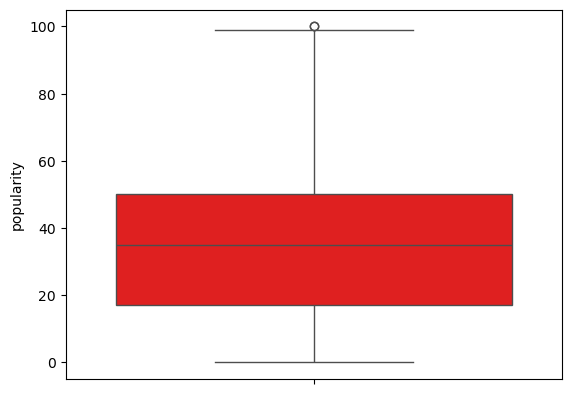

Popularity stats:
median: 35.0
mean: 33.24
first quartile: 17.0
third quartile: 50.0


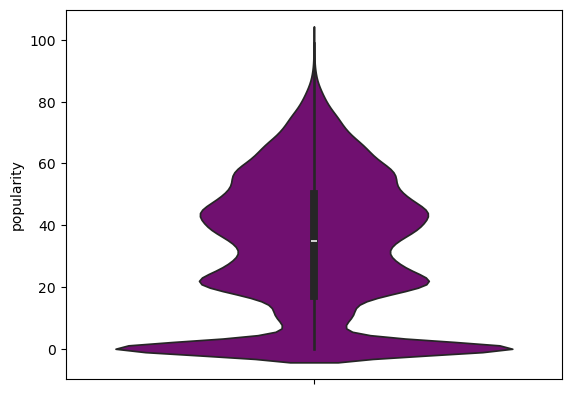

In [30]:
stat_pop = summary[summary["index"]=="popularity"]
median=stat_pop["50%"][1]
mean= stat_pop["mean"][1]
first_q = stat_pop["25%"][1]
third_q = stat_pop["75%"][1]
sns.boxplot(data=df, y="popularity", color="red", legend=True)
plt.show()
print(f"Popularity stats:\nmedian: {median}\nmean: {mean}\nfirst quartile: {first_q}\nthird quartile: {third_q}")
sns.violinplot(data=df, y="popularity", color="purple")
plt.show()

The distribution of track popularity appears clearly multimodal, suggesting the presence of distinct popularity tiers rather than a continuous gradient. 

A first concentration of observations is visible around 0, indicating a substantial number of tracks with little to no visibility. A second cluster emerges around 20, which can be interpreted as a low-popularity tier. The density increases again around 40–50, representing moderately well-known tracks, while values above 60 correspond to a smaller group of highly popular songs.

Additionally, the pronounced density near 0 highlights a strong skew toward very low popularity values. This suggests that a large portion of the dataset consists of tracks that receive minimal attention, while only a limited subset reaches higher popularity levels.

In [31]:
median_popularities = df[["track_genre", "popularity"]].groupby("track_genre").median(numeric_only=True).reset_index()
median_popularities["measure"] = "median"
min_med = median_popularities["popularity"].idxmin()
max_med = median_popularities["popularity"].idxmax()
mean_popularities= df[["track_genre", "popularity"]].groupby("track_genre").mean(numeric_only=True).reset_index()
mean_popularities["measure"] = "avg"
min_avg = mean_popularities["popularity"].idxmin()
max_avg = mean_popularities["popularity"].idxmax()

pd.concat(
        [mean_popularities[mean_popularities.index == min_avg],
         mean_popularities[mean_popularities.index == max_avg],
         mean_popularities[mean_popularities["track_genre"].isin(["pop","country"])],
         median_popularities[median_popularities.index == min_med],
         median_popularities[median_popularities.index == max_med],
         median_popularities[median_popularities["track_genre"].isin(["iranian","pop-film"])],])


#df.groupby("track_genre").count()


,track_genre,popularity,measure
59,iranian,2.210,avg
81,pop-film,59.283,avg
19,country,17.028,avg
80,pop,47.576,avg
19,country,0.000,median
80,pop,66.000,median
59,iranian,0.000,median
81,pop-film,60.000,median


In [32]:
mean_popularities[mean_popularities["track_genre"].isin(["pop","country"])]

,track_genre,popularity,measure
19,country,17.028,avg
80,pop,47.576,avg


C:\Users\ranik\AppData\Local\Temp\ipykernel_36716\1657815278.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




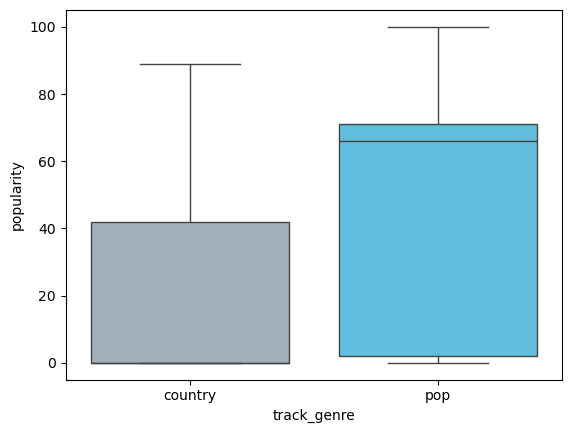

C:\Users\ranik\AppData\Local\Temp\ipykernel_36716\1657815278.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




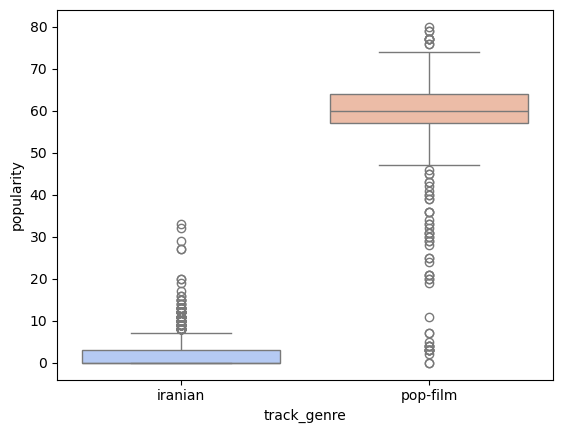

In [47]:
sns.boxplot(data=df[df["track_genre"].isin(["country","pop"])], order= ["country","pop"], x = "track_genre", y="popularity", palette = {
    "country": "#A0AEC0",   
    "pop": "#4CC9F0",       
    "iranian": "#6A4C93",   
    "pop-film": "#F6AD55"   
}, legend=True)
plt.show()
sns.boxplot(data=df[df["track_genre"].isin(["iranian", "pop-film"])], order= ["iranian", "pop-film"], x = "track_genre", y="popularity", palette="coolwarm", legend=True)
plt.show()

The boxplots show that the distributions of popularity across genres are highly skewed, with many tracks concentrated at low values and a smaller number reaching high popularity levels.

In genres such as "iranian", the median is equal to 0, indicating that at least half of the tracks receive no measurable popularity. In contrast, genres like "pop" and "pop-film" display much higher medians, suggesting that a typical track in these genres achieves a substantially higher level of visibility.

However, the presence of high-value outliers is also relevant. These represent tracks that achieve significant popularity and may be central to the overall impact of a genre. Because the mean is sensitive to these upper values, it captures the contribution of highly successful tracks, even when they are relatively rare.

For this reason, the choice between mean and median depends on the analytical objective. The median is more appropriate when the goal is to describe the typical track within a genre, while the mean is more informative when the goal is to account for the influence of highly popular tracks and the overall performance of the genre.

## 5. Genre-level aggregation

In [34]:
aggregations = {
    "popularity": "mean",
    "duration_ms": "mean",
    "explicit": "mean",
    "danceability": "mean",
    "energy": "mean",
    "key": "mean",
    "loudness": "median",
    "mode": "mean",
    "speechiness": "median",
    "acousticness": "median",
    "instrumentalness": "mean",
    "liveness": "mean",
    "valence": "mean",
    "tempo": "mean",
    "time_signature": "mean"
}

tab_ct= df.groupby("track_genre").agg(aggregations).reset_index().sort_values("popularity")


columns_to_norm = ["popularity","duration_ms","key","loudness","tempo", "time_signature"]

In [35]:
filtered = tab_ct[tab_ct["track_genre"].isin(["pop-film", "iranian"])]
tab_top_pop = filtered.set_index("track_genre").T.round(3)
tab_top_pop["difference %"] = ((tab_top_pop["pop-film"] - tab_top_pop["iranian"]) 
                               / tab_top_pop["iranian"] * 100).round(2)
tab_top_pop

track_genre,iranian,pop-film,difference %
popularity,2.210,59.283,2582.49
duration_ms,319709.537,279657.084,-12.53
explicit,0.080,0.001,-98.75
danceability,0.301,0.597,98.34
energy,0.546,0.605,10.81
key,5.135,5.296,3.14
loudness,-11.811,-7.586,-35.77
mode,0.547,0.557,1.83
speechiness,0.057,0.041,-28.07
acousticness,0.282,0.430,52.48


## 6. Correlation analysis

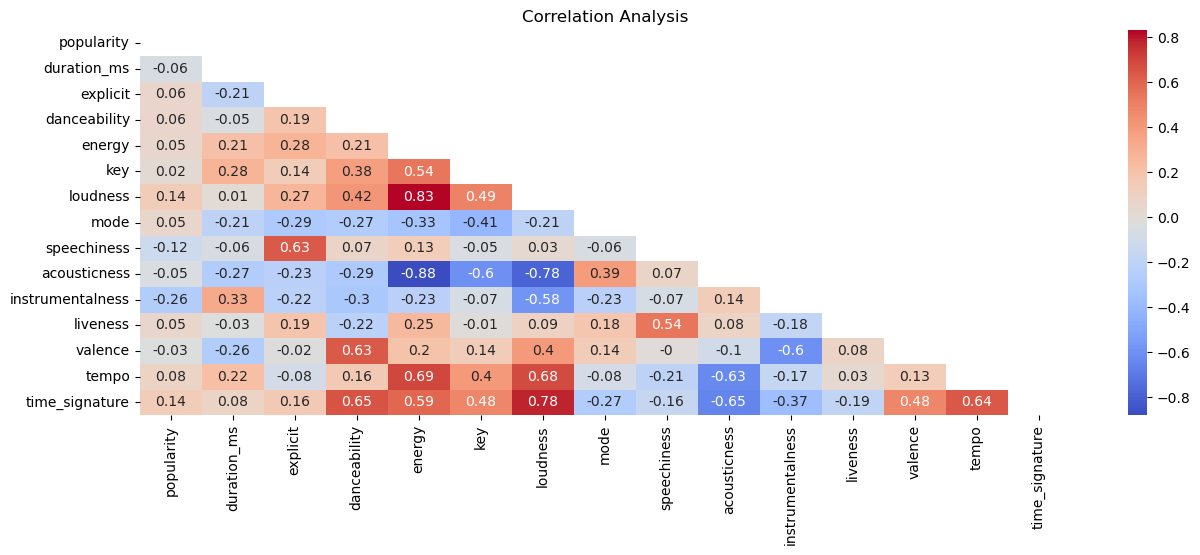

In [49]:
num = tab_ct.select_dtypes(include="number")
correlation_matrix = round(num.corr(),2)



mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(15, 5))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="coolwarm")

plt.title("Correlation Analysis")
plt.show()

The correlation matrix shows that there is no strong linear relationship between popularity and any of the audio features included in the dataset.

All correlation coefficients between popularity and the other variables are relatively small in magnitude, indicating that no single feature (such as danceability, energy, loudness, or tempo) can, on its own, explain the popularity of a track.

This suggests that popularity is likely influenced by a combination of factors rather than a single dominant characteristic. These factors may include not only audio features but also external elements such as marketing, artist reputation, playlist exposure, and broader social trends.

Therefore, while audio features are useful for describing and comparing tracks, they do not appear to be strong predictors of popularity when considered individually.

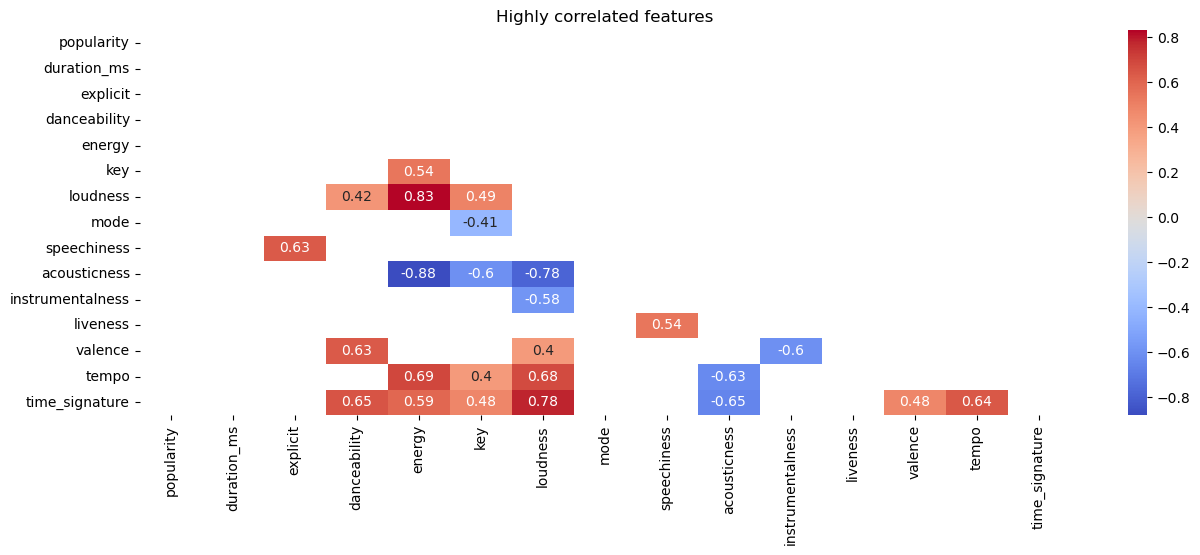

In [50]:
num = tab_ct.select_dtypes(include="number")
correlation_matrix = round(num.corr(),2)
threshold = 0.39

strong_corr = correlation_matrix.where(
    (correlation_matrix > threshold) | (correlation_matrix < -threshold)
)
mask = np.triu(np.ones_like(strong_corr, dtype=bool))
plt.figure(figsize=(15, 5))
sns.heatmap(strong_corr, mask=mask, annot=True, cmap="coolwarm")

plt.title("Highly correlated features")
plt.show()

The filtered correlation matrix highlights the presence of multicollinearity among several audio features, focusing only on stronger relationships.

Notably, there are strong positive correlations between energy and loudness (≈ 0.83), as well as between tempo and both energy and loudness. These relationships suggest that these variables capture closely related aspects of a track’s intensity and may provide overlapping information.

Similarly, strong negative correlations emerge between acousticness and features such as energy, loudness, and tempo. This reflects a clear structural contrast between acoustic and high-intensity tracks, where increases in one set of characteristics correspond to decreases in the other.

Other moderate relationships, such as between danceability and valence or speechiness and explicit content, further indicate that certain features tend to co-occur, though less strongly.

## 7. Multivariate visualization

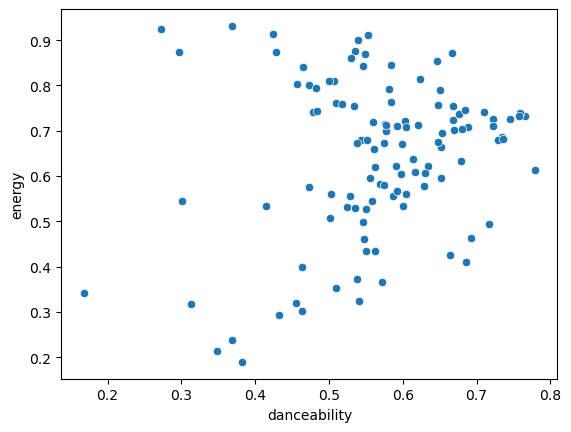

In [39]:
#scatterplot of the means between energy and danceability for each genre (data point)
sns.scatterplot(data=tab_ct, x='danceability', y='energy')
plt.show()

The scatter plot shows the relationship between danceability and energy, revealing a mild positive association between the two features.

Most observations cluster in the mid-to-high range of both variables (danceability ≈ 0.5–0.7 and energy ≈ 0.6–0.8), suggesting that many tracks combine a relatively danceable structure with a moderate to high level of intensity.

However, the relationship is not particularly strong or linear. There is a noticeable spread in energy values for similar levels of danceability, as well as several outliers where tracks are either highly energetic but not very danceable, or vice versa.

This indicates that while danceability and energy tend to increase together to some extent, they capture distinct aspects of a track. A song can be energetic without being highly danceable, and a danceable track does not necessarily require extreme energy levels.

In [40]:
'''
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(tab_ct['energy'], tab_ct['tempo'], tab_ct['acousticness'])

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
'''
#make only the specified label to appear
tab_ct["label"] = tab_ct["track_genre"].apply(
    lambda x: x if x in ["sleep", "death-metal"] else ""
)

import plotly.express as px

fig = px.scatter_3d(tab_ct, 'tempo', 'acousticness', 'energy', color = "popularity", color_continuous_scale="blues",text=tab_ct["label"])
#fig.update_traces(mode="markers")
fig.update_traces(marker=dict(size=5))
fig.show()
fig.write_html("scatter3d.html")


plt.show()

This 3D scatter plot highlights the structural differences between genres by combining energy, acousticness, and tempo, while encoding popularity through color intensity.

A clear separation emerges between the two genres. Tracks labeled as "sleep" cluster in a region characterized by high acousticness, low energy, and generally lower tempo. In contrast, "death-metal" tracks occupy the opposite region, with high energy, low acousticness, and higher tempo values.

This distribution reflects two fundamentally different production profiles: sleep music is designed to be calm, minimal, and acoustic, while death metal emphasizes intensity, speed, and amplified sound.

The color scale suggests that popularity does not strictly align with these feature combinations. Both clusters contain a range of popularity values, indicating that neither low-energy nor high-energy profiles are inherently more successful.

Overall, the plot reinforces the idea that audio features are effective at distinguishing genres, but are less informative when it comes to explaining popularity.

In [ ]:
#df.to_csv("dataset.csv", index=False)

## Distance-based comparison between genres

To move beyond pairwise relationships and analyze genres in a more holistic way, we introduce a distance-based approach in a multidimensional feature space.

Each genre is represented by a vector of aggregated audio features (e.g., danceability, energy, acousticness, tempo, etc.). These features jointly describe the overall "profile" of a genre.

To compare genres, we compute the Euclidean distance between their corresponding feature vectors. This distance measures how similar or dissimilar two genres are across all selected variables:
- smaller distances indicate similar audio profiles  
- larger distances indicate more distinct genres  

Before computing distances, selected variables are normalized to ensure comparability across different scales (e.g., duration vs. danceability). This prevents variables with larger numerical ranges from dominating the distance calculation.

The resulting distance matrix provides a global view of similarity relationships between genres. From this matrix, we extract:
- the most similar genre pairs (smallest distances)  
- the most dissimilar genre pairs (largest distances)  

This approach allows us to identify clusters of similar genres and highlight which genres are structurally close or far apart in terms of their audio characteristics.

In [ ]:
# DISTANCE ANALYSIS: Let's define an n-dimensional distance measure
#interesting_variables = ["danceability", "energy", "loudness", "mode", "speechiness", "acousticness", "instrumentalness", "liveness", "valence"]
interesting_variables = [
    "popularity",
    "duration_ms",
    "explicit",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature"
]



def distance(a, b, n):
    dist = 0
    for i in range(n):
        dist = dist + ((a[i] - b[i])**2)
    return dist**(0.5)

table_greg = tab_ct.copy()
table_greg = table_greg.set_index("track_genre")
# normalize loudness!
table_greg = table_greg[interesting_variables]
columns_to_norm = ["popularity","duration_ms","key","loudness","tempo", "time_signature"]
for column in columns_to_norm:
    table_greg[column] = (table_greg[column] - table_greg[column].min()) / (table_greg[column].max() - table_greg[column].min())
m = len(table_greg.index)
n = len(table_greg.columns)
table_greg[:20]
dist_matrix = np.empty((m,m))
for i in range(m):
    for j in range(m):
        dist_matrix[i,j] = distance(table_greg.loc[table_greg.index[i]], table_greg.loc[table_greg.index[j]], n)

dist_df = pd.DataFrame(dist_matrix, index=table_greg.index, columns=table_greg.index)
dist_max = dist_df.values.max()
dist_norm = dist_df / dist_max
dist_norm.head()

s = dist_norm.where(np.triu(np.ones(dist_norm.shape), k=1).astype(bool)).stack() 
top10 = s.nlargest(20)
close10 = s.nsmallest(20)

C:\Users\ranik\AppData\Local\Temp\ipykernel_36716\4019451120.py:26: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



In [53]:
def pretty_print(title, data):
    print(f"\n{title}")
    print("-" * len(title))
    print(data.to_string())

pretty_print("TOP 20 MOST DISSIMILAR GENRE PAIRS", top10)
pretty_print("TOP 20 MOST SIMILAR GENRE PAIRS", close10)


TOP 20 MOST DISSIMILAR GENRE PAIRS
----------------------------------
track_genre     track_genre
happy           sleep          1.000000
drum-and-bass   sleep          0.995641
chicago-house   sleep          0.994551
hardstyle       sleep          0.984925
party           sleep          0.981020
j-idol          sleep          0.970500
breakbeat       sleep          0.969893
reggae          sleep          0.965418
reggaeton       sleep          0.963152
latin           sleep          0.960601
detroit-techno  sleep          0.960420
latino          sleep          0.959042
sleep           forro          0.942736
edm             sleep          0.939661
sleep           ska            0.936156
dancehall       sleep          0.935522
dance           sleep          0.934790
sleep           hardcore       0.934728
                metal          0.927381
house           sleep          0.927334

TOP 20 MOST SIMILAR GENRE PAIRS
-------------------------------
track_genre        track_genre      

## Interpretation of the Distance Analysis

### 1. Extreme Dissimilarity and Boundary Genres

The distance analysis reveals that certain genres occupy extreme positions in the feature space. In particular, **sleep** appears repeatedly among the most distant pairs, often contrasted with genres such as **happy**, **drum-and-bass**, **hardstyle**, **party**, and **metal**.

This indicates that *sleep* lies at the edge of the multidimensional space, likely due to its combination of very low energy and tempo with high acousticness. In contrast, the opposing genres are characterized by high intensity, rhythmic structure, and amplified sound.

Substantively, this reflects a meaningful contrast: genres designed for relaxation are structurally distant from those designed for stimulation. In this sense, *sleep* can be interpreted as a boundary genre, clearly separated from most high-activation musical styles.

### 2. Strong Similarities and Genre Families

The most similar genre pairs are also highly interpretable. Some pairs are nearly identical in naming and profile, such as **singer-songwriter** and **songwriter**, suggesting minimal differentiation in the dataset.

Other pairs reflect clear stylistic proximity, including:
- **punk-rock** and **punk**
- **indie** and **indie-pop**
- **hard-rock** and **metal**
- **house** with **electro** or **edm**
- **deep-house** with **progressive-house**

These relationships indicate that many genres belong to broader stylistic families, sharing similar audio characteristics and production patterns.

### 3. Implications for Genre Structure

The observed similarities suggest that the genre space is not flat, but structured. Rather than being independent categories, many genres cluster around common profiles, reflecting underlying dimensions such as intensity, acousticness, or rhythmic complexity.

The distance matrix therefore provides more than pairwise comparisons: it reveals the presence of an underlying organization in the data.

### 4. Toward Clustering Approaches

Given this structure, a natural next step is to apply clustering techniques (e.g., hierarchical clustering or k-means) to formally identify groups of similar genres.

Clustering would allow us to move from individual pairwise relationships to a global segmentation of the genre space, making it possible to:
- identify coherent genre families  
- detect outliers or boundary genres  
- better understand the latent structure of musical styles  